# 07 — Advanced Modeling: LightGBM and CatBoost

**Development scope:** Kalimantan only.

## Objective

Notebook 05 established the main tabular benchmark using the same 20 **Fire History + Weather** features across Logistic Regression, Random Forest, Gradient Boosting, and XGBoost.

This notebook evaluates two additional nonlinear boosting methods:

- **LightGBM**
- **CatBoost**

The purpose is to test whether nonlinear tree-based boosting can improve the established Logistic Regression benchmark **without changing the input information or temporal evaluation protocol**.

### Experimental principle

All advanced models use exactly the same:

- 20 benchmark features,
- target,
- temporal train/validation/test split,
- earlier temporal tuning split,
- primary metric (PR-AUC / Average Precision).

The August 2026 validation set is not used for hyperparameter tuning. September 2026 is reserved for final test reporting.

> **Important:** This notebook does not introduce AQ, FWI, or spatial-lag features. Those are separate experiments.


In [2]:
# 1. Imports and project configuration

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "karhut_ml_dataset_kalimantan.csv"
RESULTS_DIR = PROJECT_ROOT / "data" / "processed" / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Results directory:", RESULTS_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Run Notebook 04 first."
    )


Project root: c:\Users\Asus\Documents\skripsi-karhut
Dataset: c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_dataset_kalimantan.csv
Results directory: c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results


In [3]:
# 2. Load the ML dataset

ml_data = pd.read_csv(DATA_PATH, parse_dates=["date"])

ml_data = (
    ml_data
    .sort_values(["cell_id", "date"])
    .reset_index(drop=True)
)

print("Dataset shape:", ml_data.shape)
print("Date range:", ml_data["date"].min().date(), "→", ml_data["date"].max().date())
print("Unique cells:", ml_data["cell_id"].nunique())

display(ml_data.head())


Dataset shape: (34272, 29)
Date range: 2026-05-08 → 2026-09-10
Unique cells: 272


,region,cell_id,date,grid_lat,grid_lon,weather_lat,weather_lon,weather_distance_km,fire_count_lag1,fire_count_lag3,...,temperature_max,relative_humidity_mean,precipitation_sum,boundary_layer_height_mean,vapour_pressure_deficit_mean,wind_speed_mean,wind_speed_max,wind_u_mean,wind_v_mean,target_fire_active_t1
0,Kalimantan,Kalimantan_-0.75_108.00,2026-05-08,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,28.9,82.750000,47.8,322.083333,0.630833,6.679167,15.0,-3.475577,3.189461,0.0
1,Kalimantan,Kalimantan_-0.75_108.00,2026-05-09,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,29.5,79.916667,6.2,430.416667,0.772500,9.020833,14.5,5.493204,5.629225,0.0
2,Kalimantan,Kalimantan_-0.75_108.00,2026-05-10,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,31.1,62.500000,0.0,643.125000,1.646667,3.325000,7.1,-0.728517,-0.354466,0.0
3,Kalimantan,Kalimantan_-0.75_108.00,2026-05-11,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,31.2,61.375000,0.0,780.208333,1.700417,7.683333,14.7,-0.473697,-4.136161,0.0
4,Kalimantan,Kalimantan_-0.75_108.00,2026-05-12,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,30.5,70.125000,1.2,545.625000,1.235417,11.966667,20.5,-10.974184,1.647696,0.0


## 3. Define the identical 20-feature benchmark

These are the same 20 features used by Notebook 05.

### Fire History — 10 features

- 3 lagged fire-count features
- 3 lagged FRP features
- 2 rolling fire-count features
- 2 rolling FRP features

### Weather — 10 features

- temperature
- relative humidity
- precipitation
- boundary layer height
- vapour pressure deficit
- wind speed and wind-vector components


In [4]:
fire_history_features = [
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7"
]

weather_features = [
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean"
]

features_20 = fire_history_features + weather_features
target_col = "target_fire_active_t1"

assert len(features_20) == 20
assert target_col not in features_20

missing = sorted(set(features_20 + [target_col]) - set(ml_data.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Number of benchmark features:", len(features_20))
for i, feature in enumerate(features_20, 1):
    print(f"{i:02d}. {feature}")


Number of benchmark features: 20
01. fire_count_lag1
02. fire_count_lag3
03. fire_count_lag7
04. frp_sum_lag1
05. frp_sum_lag3
06. frp_sum_lag7
07. fire_count_roll3
08. fire_count_roll7
09. frp_sum_roll3
10. frp_sum_roll7
11. temperature_mean
12. temperature_max
13. relative_humidity_mean
14. precipitation_sum
15. boundary_layer_height_mean
16. vapour_pressure_deficit_mean
17. wind_speed_mean
18. wind_speed_max
19. wind_u_mean
20. wind_v_mean


## 4. Temporal evaluation protocol

The split follows Notebook 05 exactly:

| Split | Period | Purpose |
|---|---|---|
| Tuning train | 2026-05-08 – 2026-06-30 | Hyperparameter selection |
| Tuning validation | 2026-07-01 – 2026-07-31 | Hyperparameter selection |
| Final train | 2026-05-08 – 2026-07-31 | Retrain selected configuration |
| Final validation | August 2026 | Model comparison |
| Test | September 2026 | Final out-of-sample evaluation |

The August validation set is therefore **untouched during tuning**.


In [5]:
# 5. Create temporal splits

tune_train = ml_data[
    (ml_data["date"] >= "2026-05-08") &
    (ml_data["date"] < "2026-07-01")
].copy()

tune_val = ml_data[
    (ml_data["date"] >= "2026-07-01") &
    (ml_data["date"] < "2026-08-01")
].copy()

train_data = ml_data[
    (ml_data["date"] >= "2026-05-08") &
    (ml_data["date"] < "2026-08-01")
].copy()

val_data = ml_data[
    (ml_data["date"] >= "2026-08-01") &
    (ml_data["date"] < "2026-09-01")
].copy()

test_data = ml_data[
    ml_data["date"] >= "2026-09-01"
].copy()

X_tune_train = tune_train[features_20]
y_tune_train = tune_train[target_col].astype(int)

X_tune_val = tune_val[features_20]
y_tune_val = tune_val[target_col].astype(int)

X_train = train_data[features_20]
y_train = train_data[target_col].astype(int)

X_val = val_data[features_20]
y_val = val_data[target_col].astype(int)

X_test = test_data[features_20]
y_test = test_data[target_col].astype(int)

split_summary = pd.DataFrame({
    "Split": ["Tuning Train", "Tuning Validation", "Final Train", "Final Validation", "Test"],
    "Start": [
        tune_train["date"].min(),
        tune_val["date"].min(),
        train_data["date"].min(),
        val_data["date"].min(),
        test_data["date"].min()
    ],
    "End": [
        tune_train["date"].max(),
        tune_val["date"].max(),
        train_data["date"].max(),
        val_data["date"].max(),
        test_data["date"].max()
    ],
    "Rows": [
        len(tune_train), len(tune_val), len(train_data), len(val_data), len(test_data)
    ],
    "Positive Rate": [
        y_tune_train.mean(), y_tune_val.mean(), y_train.mean(), y_val.mean(), y_test.mean()
    ]
})

display(split_summary)


,Split,Start,End,Rows,Positive Rate
0,Tuning Train,2026-05-08,2026-06-30,14688,0.082721
1,Tuning Validation,2026-07-01,2026-07-31,8432,0.158681
2,Final Train,2026-05-08,2026-07-31,23120,0.110424
3,Final Validation,2026-08-01,2026-08-31,8432,0.339184
4,Test,2026-09-01,2026-09-10,2720,0.319485


In [6]:
# 6. Class-imbalance weights

# We calculate the positive-class weight from each training portion only.
neg_tune = int((y_tune_train == 0).sum())
pos_tune = int((y_tune_train == 1).sum())
scale_pos_weight_tune = neg_tune / pos_tune

neg_train = int((y_train == 0).sum())
pos_train = int((y_train == 1).sum())
scale_pos_weight_train = neg_train / pos_train

print("Tuning train:")
print("  negatives:", neg_tune)
print("  positives:", pos_tune)
print("  scale_pos_weight:", scale_pos_weight_tune)

print("\nFinal train:")
print("  negatives:", neg_train)
print("  positives:", pos_train)
print("  scale_pos_weight:", scale_pos_weight_train)


Tuning train:
  negatives: 13473
  positives: 1215
  scale_pos_weight: 11.088888888888889

Final train:
  negatives: 20567
  positives: 2553
  scale_pos_weight: 8.056012534273403


In [7]:
# 7. Evaluation helpers

def metric_dict(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Threshold": threshold
    }


def print_metrics(title, metrics):
    print(f"=== {title} ===")
    for key, value in metrics.items():
        print(f"{key:10s}: {value:.6f}")


def best_f1_threshold(y_true, y_prob, start=0.30, stop=0.81, step=0.01):
    rows = []

    for threshold in np.arange(start, stop, step):
        threshold = round(float(threshold), 2)
        pred = (y_prob >= threshold).astype(int)

        rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred, zero_division=0)
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["F1", "Recall", "Threshold"],
            ascending=[False, False, True]
        )
        .reset_index(drop=True)
    )


## 8. Load the established Logistic Regression benchmark

Notebook 05 saves the main benchmark to:

```text
data/processed/model_results/benchmark_validation_results.csv
```

This notebook reads that result rather than retraining Logistic Regression. This keeps Notebook 05 as the owner of the main benchmark and avoids unnecessary duplicate computation.

The advanced models below must use the same 20-feature dataset and August validation period.


In [8]:
benchmark_path = RESULTS_DIR / "benchmark_validation_results.csv"

if not benchmark_path.exists():
    raise FileNotFoundError(
        f"{benchmark_path} not found. Run Notebook 05 first so that the established "
        "20-feature benchmark is available."
    )

benchmark_results = pd.read_csv(benchmark_path)

required_benchmark_cols = {
    "Model", "PR-AUC", "Precision", "Recall", "F1", "Accuracy", "Threshold"
}

missing_benchmark_cols = sorted(required_benchmark_cols - set(benchmark_results.columns))
if missing_benchmark_cols:
    raise ValueError(
        f"Benchmark file is missing columns: {missing_benchmark_cols}"
    )

display(benchmark_results)


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold
0,Logistic Regression,0.901149,0.677419,0.925175,0.782146,0.825190,0.5
1,Random Forest (Tuned),0.853942,0.763805,0.836713,0.798598,0.856855,0.5
2,Gradient Boosting (Tuned),0.893740,0.694522,0.953147,0.803537,0.841912,0.5
3,XGBoost (Tuned),0.894462,0.685729,0.955944,0.798598,0.836456,0.5


## 9. LightGBM baseline

LightGBM is a gradient-boosted decision-tree method that can model nonlinear relationships and feature interactions.

The baseline is included for continuity with the earlier experiment. Hyperparameter tuning is performed separately using the July temporal validation period.


In [9]:
from lightgbm import LGBMClassifier

lgbm_baseline = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    scale_pos_weight=scale_pos_weight_train,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgbm_baseline.fit(X_train, y_train)

lgbm_baseline_val_prob = lgbm_baseline.predict_proba(X_val)[:, 1]
lgbm_baseline_val_metrics = metric_dict(
    y_val,
    lgbm_baseline_val_prob,
    threshold=0.5
)

print_metrics(
    "LightGBM Baseline — August Validation @ 0.50",
    lgbm_baseline_val_metrics
)


=== LightGBM Baseline — August Validation @ 0.50 ===
PR-AUC    : 0.860434
Precision : 0.718478
Recall    : 0.864685
F1        : 0.784830
Accuracy  : 0.839184
Threshold : 0.500000


## 10. LightGBM temporal tuning

Only the May–June tuning-train period and July tuning-validation period are used here.

The August validation period remains untouched.


In [10]:
lgbm_configs = [
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "num_leaves": 15,
        "max_depth": -1,
        "min_child_samples": 20
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "num_leaves": 15,
        "max_depth": -1,
        "min_child_samples": 20
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 30
    }
]

lgbm_tuning_rows = []

for i, config in enumerate(lgbm_configs, 1):
    model = LGBMClassifier(
        objective="binary",
        scale_pos_weight=scale_pos_weight_tune,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
        **config
    )

    model.fit(X_tune_train, y_tune_train)
    prob = model.predict_proba(X_tune_val)[:, 1]

    lgbm_tuning_rows.append({
        "Config": f"LGBM-{i}",
        **config,
        "PR-AUC": average_precision_score(y_tune_val, prob)
    })

lgbm_tuning_results = (
    pd.DataFrame(lgbm_tuning_rows)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

display(lgbm_tuning_results)


,Config,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,PR-AUC
0,LGBM-2,300,0.03,15,-1,20,0.578260
1,LGBM-1,200,0.05,15,-1,20,0.570570
2,LGBM-4,500,0.03,31,-1,30,0.567806
3,LGBM-3,300,0.05,31,-1,20,0.552942


In [11]:
# 11. Select LightGBM configuration and retrain on the full May–July training period

best_lgbm_row = lgbm_tuning_results.iloc[0]

best_lgbm_config = {
    "n_estimators": int(best_lgbm_row["n_estimators"]),
    "learning_rate": float(best_lgbm_row["learning_rate"]),
    "num_leaves": int(best_lgbm_row["num_leaves"]),
    "max_depth": int(best_lgbm_row["max_depth"]),
    "min_child_samples": int(best_lgbm_row["min_child_samples"])
}

print("Selected LightGBM configuration:")
print(best_lgbm_config)

lgbm_tuned = LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight_train,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
    **best_lgbm_config
)

lgbm_tuned.fit(X_train, y_train)

lgbm_val_prob = lgbm_tuned.predict_proba(X_val)[:, 1]
lgbm_val_metrics = metric_dict(
    y_val,
    lgbm_val_prob,
    threshold=0.5
)

print()
print_metrics(
    "LightGBM Tuned — August Validation @ 0.50",
    lgbm_val_metrics
)


Selected LightGBM configuration:
{'n_estimators': 300, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 20}

=== LightGBM Tuned — August Validation @ 0.50 ===
PR-AUC    : 0.888358
Precision : 0.674950
Recall    : 0.949650
F1        : 0.789076
Accuracy  : 0.827799
Threshold : 0.500000


## 12. CatBoost availability check

CatBoost is the main additional nonlinear candidate in this notebook.

It is evaluated with numeric features only; no categorical encoding is required because all 20 benchmark variables are numerical.


In [12]:
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print("CatBoost import: OK")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost is not installed.")
    print("Install it in the project environment with:")
    print("    pip install catboost")
    print("Then restart the kernel and rerun this notebook.")


CatBoost import: OK


## 13. CatBoost temporal tuning

The tuning protocol is identical to LightGBM:

- tune on May–June,
- select hyperparameters on July,
- retrain the selected configuration on May–July,
- evaluate on untouched August validation.

The same training-only class-imbalance weighting protocol is used.


In [13]:
catboost_tuning_results = pd.DataFrame()

if CATBOOST_AVAILABLE:

    catboost_configs = [
        {
            "iterations": 300,
            "depth": 4,
            "learning_rate": 0.05,
            "l2_leaf_reg": 3
        },
        {
            "iterations": 500,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 3
        },
        {
            "iterations": 500,
            "depth": 6,
            "learning_rate": 0.03,
            "l2_leaf_reg": 5
        },
        {
            "iterations": 700,
            "depth": 5,
            "learning_rate": 0.02,
            "l2_leaf_reg": 5
        }
    ]

    rows = []

    for i, config in enumerate(catboost_configs, 1):
        model = CatBoostClassifier(
            **config,
            loss_function="Logloss",
            scale_pos_weight=scale_pos_weight_tune,
            random_seed=RANDOM_STATE,
            verbose=False,
            thread_count=-1,
            allow_writing_files=False
        )

        model.fit(X_tune_train, y_tune_train)

        prob = model.predict_proba(X_tune_val)[:, 1]

        rows.append({
            "Config": f"CatBoost-{i}",
            **config,
            "PR-AUC": average_precision_score(y_tune_val, prob)
        })

    catboost_tuning_results = (
        pd.DataFrame(rows)
        .sort_values("PR-AUC", ascending=False)
        .reset_index(drop=True)
    )

    display(catboost_tuning_results)

else:
    print("CatBoost tuning skipped because the package is unavailable.")


,Config,iterations,depth,learning_rate,l2_leaf_reg,PR-AUC
0,CatBoost-4,700,5,0.02,5,0.572016
1,CatBoost-3,500,6,0.03,5,0.563716
2,CatBoost-1,300,4,0.05,3,0.553326
3,CatBoost-2,500,5,0.03,3,0.549292


In [14]:
# 14. Select CatBoost configuration and retrain on the full May–July training period

catboost_final = None
catboost_val_prob = None
catboost_val_metrics = None
catboost_selected = None

if CATBOOST_AVAILABLE and not catboost_tuning_results.empty:

    best_catboost_row = catboost_tuning_results.iloc[0]

    catboost_selected = {
        "iterations": int(best_catboost_row["iterations"]),
        "depth": int(best_catboost_row["depth"]),
        "learning_rate": float(best_catboost_row["learning_rate"]),
        "l2_leaf_reg": float(best_catboost_row["l2_leaf_reg"])
    }

    print("Selected CatBoost configuration:")
    print(catboost_selected)

    catboost_final = CatBoostClassifier(
        **catboost_selected,
        loss_function="Logloss",
        scale_pos_weight=scale_pos_weight_train,
        random_seed=RANDOM_STATE,
        verbose=False,
        thread_count=-1,
        allow_writing_files=False
    )

    catboost_final.fit(X_train, y_train)

    catboost_val_prob = catboost_final.predict_proba(X_val)[:, 1]

    catboost_val_metrics = metric_dict(
        y_val,
        catboost_val_prob,
        threshold=0.5
    )

    print()
    print_metrics(
        "CatBoost Tuned — August Validation @ 0.50",
        catboost_val_metrics
    )

else:
    print("CatBoost final validation skipped.")


Selected CatBoost configuration:
{'iterations': 700, 'depth': 5, 'learning_rate': 0.02, 'l2_leaf_reg': 5.0}

=== CatBoost Tuned — August Validation @ 0.50 ===
PR-AUC    : 0.893969
Precision : 0.689769
Recall    : 0.950000
F1        : 0.799235
Accuracy  : 0.838117
Threshold : 0.500000


## 15. Advanced-model validation comparison

This table compares the advanced models with the established 20-feature benchmark from Notebook 05.

**Model selection must be based on the August validation period.** The September test set is not used here.


In [15]:
advanced_validation_rows = []

for _, row in benchmark_results.iterrows():
    advanced_validation_rows.append({
        "Model": row["Model"],
        "PR-AUC": row["PR-AUC"],
        "Precision": row["Precision"],
        "Recall": row["Recall"],
        "F1": row["F1"],
        "Accuracy": row["Accuracy"],
        "Threshold": row["Threshold"],
        "Source": "Notebook 05"
    })

advanced_validation_rows.append({
    "Model": "LightGBM (Tuned)",
    **lgbm_val_metrics,
    "Source": "Notebook 07"
})

if catboost_val_metrics is not None:
    advanced_validation_rows.append({
        "Model": "CatBoost (Tuned)",
        **catboost_val_metrics,
        "Source": "Notebook 07"
    })

advanced_validation_results = pd.DataFrame(advanced_validation_rows)

display(
    advanced_validation_results[
        ["Model", "PR-AUC", "Precision", "Recall", "F1", "Accuracy", "Threshold", "Source"]
    ]
)


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold,Source
0,Logistic Regression,0.901149,0.677419,0.925175,0.782146,0.825190,0.5,Notebook 05
1,Random Forest (Tuned),0.853942,0.763805,0.836713,0.798598,0.856855,0.5,Notebook 05
2,Gradient Boosting (Tuned),0.893740,0.694522,0.953147,0.803537,0.841912,0.5,Notebook 05
3,XGBoost (Tuned),0.894462,0.685729,0.955944,0.798598,0.836456,0.5,Notebook 05
4,LightGBM (Tuned),0.888358,0.674950,0.949650,0.789076,0.827799,0.5,Notebook 07
5,CatBoost (Tuned),0.893969,0.689769,0.950000,0.799235,0.838117,0.5,Notebook 07


## 16. Validation PR-AUC comparison

PR-AUC is the primary metric. The plot is descriptive and does not imply a universal ranking beyond this dataset and evaluation protocol.


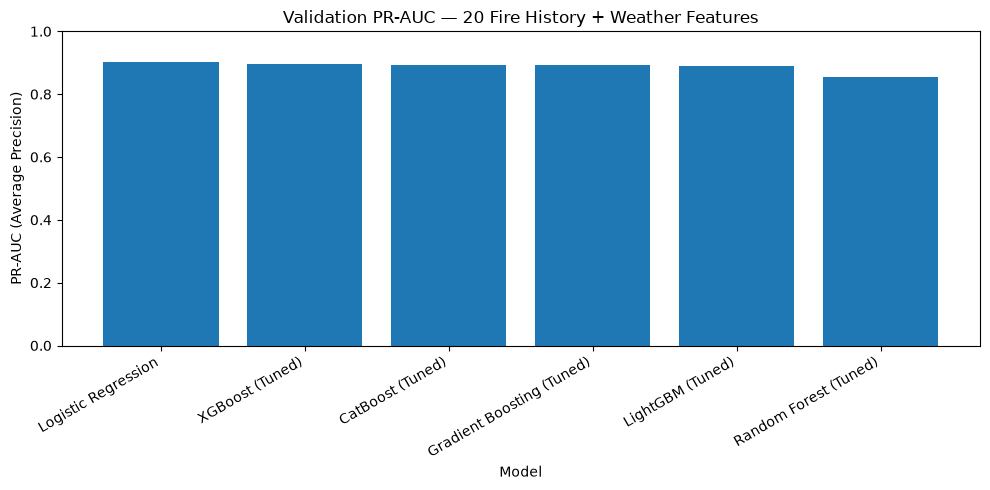

In [16]:
plot_df = advanced_validation_results.sort_values("PR-AUC", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["PR-AUC"])
plt.ylabel("PR-AUC (Average Precision)")
plt.xlabel("Model")
plt.title("Validation PR-AUC — 20 Fire History + Weather Features")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 17. Decision rule for the advanced candidate

The established Logistic Regression validation PR-AUC is read directly from Notebook 05.

The advanced-model experiment answers:

> Does a nonlinear boosting model improve validation PR-AUC when the feature set and temporal protocol are held constant?

If an advanced model has higher August PR-AUC than the Logistic Regression benchmark, it becomes a candidate for final model consideration.

If not, the experiment provides evidence that increasing model nonlinearity did not improve predictive performance under the current data representation and evaluation setup.

This is a **dataset-specific empirical result**, not a universal statement about the algorithms.


In [17]:
lr_rows = benchmark_results[
    benchmark_results["Model"].str.contains("Logistic Regression", case=False, regex=False)
]

if lr_rows.empty:
    raise ValueError("Logistic Regression result not found in Notebook 05 benchmark output.")

lr_validation_prauc = float(lr_rows.iloc[0]["PR-AUC"])

candidate_rows = advanced_validation_results[
    advanced_validation_results["Model"].isin(["LightGBM (Tuned)", "CatBoost (Tuned)"])
].copy()

candidate_rows["Delta_vs_LR"] = candidate_rows["PR-AUC"] - lr_validation_prauc
candidate_rows["Validation_PR_AUC_above_LR"] = (
    candidate_rows["PR-AUC"] > lr_validation_prauc
)

print(f"Established Logistic Regression validation PR-AUC: {lr_validation_prauc:.6f}")
display(candidate_rows[[
    "Model",
    "PR-AUC",
    "Delta_vs_LR",
    "Validation_PR_AUC_above_LR"
]])


Established Logistic Regression validation PR-AUC: 0.901149


,Model,PR-AUC,Delta_vs_LR,Validation_PR_AUC_above_LR
4,LightGBM (Tuned),0.888358,-0.012791,False
5,CatBoost (Tuned),0.893969,-0.007179,False


## 18. Operating thresholds for advanced candidates

PR-AUC itself does not require a threshold.

For threshold-based metrics, the operating threshold is selected using **August validation only**, using F1 as the operating-point criterion.

The test set remains untouched during this step.


In [18]:
advanced_thresholds = {}

for model_name, prob in [
    ("LightGBM (Tuned)", lgbm_val_prob),
    ("CatBoost (Tuned)", catboost_val_prob)
]:
    if prob is None:
        continue

    threshold_table = best_f1_threshold(y_val, prob)

    advanced_thresholds[model_name] = float(
        threshold_table.iloc[0]["Threshold"]
    )

    print(f"{model_name} selected threshold:",
          advanced_thresholds[model_name])


LightGBM (Tuned) selected threshold: 0.69
CatBoost (Tuned) selected threshold: 0.74


## 19. Final test evaluation

September is now evaluated using the configurations selected before looking at test outcomes.

Test metrics are reported for both advanced candidates when available. These results are **not used to tune hyperparameters or choose the model**.


In [19]:
def evaluate_test(model, X, y, threshold):
    prob = model.predict_proba(X)[:, 1]
    metrics = metric_dict(y, prob, threshold)
    cm = confusion_matrix(y, (prob >= threshold).astype(int))
    return metrics, cm, prob


test_rows = []
test_confusion_matrices = {}

# LightGBM
lgbm_test_threshold = advanced_thresholds["LightGBM (Tuned)"]

lgbm_test_metrics, lgbm_test_cm, lgbm_test_prob = evaluate_test(
    lgbm_tuned,
    X_test,
    y_test,
    lgbm_test_threshold
)

test_rows.append({
    "Model": "LightGBM (Tuned)",
    **lgbm_test_metrics
})
test_confusion_matrices["LightGBM (Tuned)"] = lgbm_test_cm

# CatBoost, if available
if catboost_final is not None and catboost_val_prob is not None:

    catboost_test_threshold = advanced_thresholds["CatBoost (Tuned)"]

    catboost_test_metrics, catboost_test_cm, catboost_test_prob = evaluate_test(
        catboost_final,
        X_test,
        y_test,
        catboost_test_threshold
    )

    test_rows.append({
        "Model": "CatBoost (Tuned)",
        **catboost_test_metrics
    })
    test_confusion_matrices["CatBoost (Tuned)"] = catboost_test_cm

advanced_test_results = pd.DataFrame(test_rows)

display(
    advanced_test_results[
        ["Model", "PR-AUC", "Precision", "Recall", "F1", "Accuracy", "Threshold"]
    ]
)

for model_name, cm in test_confusion_matrices.items():
    print(f"\n{model_name} — Test Confusion Matrix")
    print(cm)


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold
0,LightGBM (Tuned),0.893410,0.711607,0.917146,0.801408,0.854779,0.69
1,CatBoost (Tuned),0.903152,0.732902,0.912543,0.812916,0.865809,0.74



LightGBM (Tuned) — Test Confusion Matrix
[[1528  323]
 [  72  797]]

CatBoost (Tuned) — Test Confusion Matrix
[[1562  289]
 [  76  793]]


## 20. Feature importance diagnostics

Tree-based feature importance is useful for describing which variables the fitted model used most strongly.

It should be interpreted as a **model-specific predictive diagnostic**, not as a causal effect.


,Importance
fire_count_roll7,16.191526
frp_sum_roll7,12.083980
precipitation_sum,9.825012
temperature_mean,9.511586
boundary_layer_height_mean,6.816942
wind_u_mean,6.525148
temperature_max,6.135678
wind_speed_max,5.708165
wind_v_mean,5.210823
wind_speed_mean,4.505512


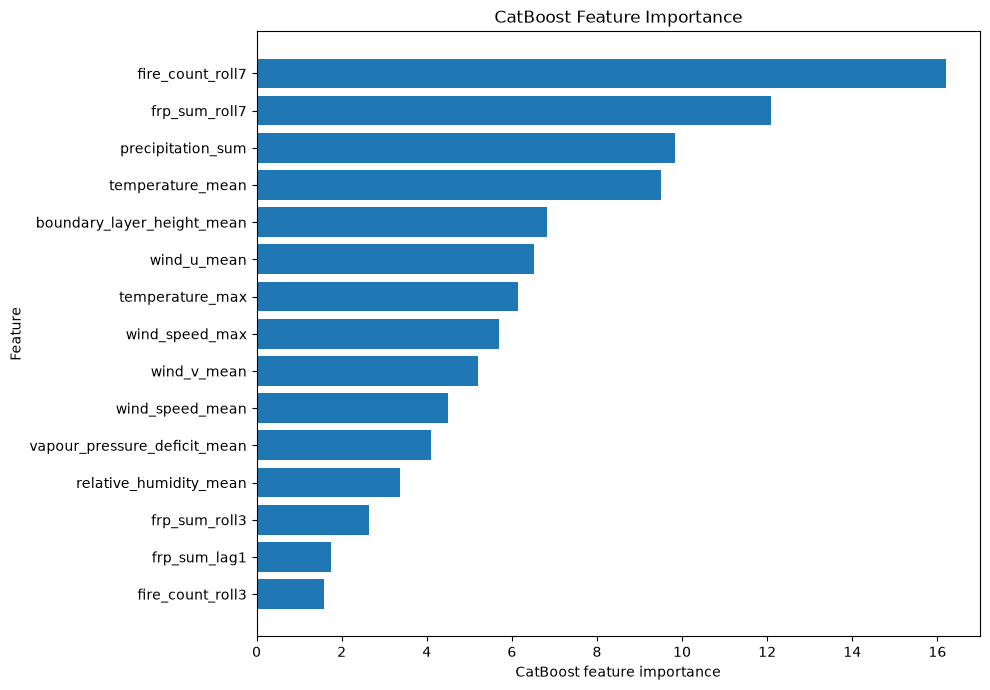

,Importance
wind_u_mean,465
precipitation_sum,410
wind_speed_max,401
temperature_mean,390
boundary_layer_height_mean,320
wind_v_mean,305
fire_count_roll7,283
wind_speed_mean,277
temperature_max,276
vapour_pressure_deficit_mean,207


In [20]:
if catboost_final is not None:
    cat_importance = pd.Series(
        catboost_final.get_feature_importance(),
        index=features_20
    ).sort_values(ascending=False)

    display(cat_importance.head(20).to_frame("Importance"))

    top_cat = cat_importance.head(15).sort_values()

    plt.figure(figsize=(10, 7))
    plt.barh(top_cat.index, top_cat.values)
    plt.xlabel("CatBoost feature importance")
    plt.ylabel("Feature")
    plt.title("CatBoost Feature Importance")
    plt.tight_layout()
    plt.show()

lgbm_importance = pd.Series(
    lgbm_tuned.feature_importances_,
    index=features_20
).sort_values(ascending=False)

display(lgbm_importance.head(20).to_frame("Importance"))


## 21. Save advanced-model results

Outputs are stored under:

```text
data/processed/model_results/
```

Saved files:

- `advanced_validation_results.csv`
- `advanced_test_results.csv`
- `lightgbm_tuning_results.csv`
- `catboost_tuning_results.csv` (when CatBoost is available)
- `advanced_model_configurations.csv`
- `catboost_feature_importance.csv` (when available)
- `lightgbm_feature_importance.csv`


In [21]:
advanced_validation_output = RESULTS_DIR / "advanced_validation_results.csv"
advanced_test_output = RESULTS_DIR / "advanced_test_results.csv"
lgbm_tuning_output = RESULTS_DIR / "lightgbm_tuning_results.csv"
catboost_tuning_output = RESULTS_DIR / "catboost_tuning_results.csv"
config_output = RESULTS_DIR / "advanced_model_configurations.csv"
lgbm_importance_output = RESULTS_DIR / "lightgbm_feature_importance.csv"
cat_importance_output = RESULTS_DIR / "catboost_feature_importance.csv"

advanced_validation_results.to_csv(
    advanced_validation_output,
    index=False
)

advanced_test_results.to_csv(
    advanced_test_output,
    index=False
)

lgbm_tuning_results.to_csv(
    lgbm_tuning_output,
    index=False
)

if not catboost_tuning_results.empty:
    catboost_tuning_results.to_csv(
        catboost_tuning_output,
        index=False
    )

config_rows = [
    {
        "Model": "LightGBM (Tuned)",
        **best_lgbm_config
    }
]

if catboost_selected is not None:
    config_rows.append({
        "Model": "CatBoost (Tuned)",
        **catboost_selected
    })

pd.DataFrame(config_rows).to_csv(
    config_output,
    index=False
)

lgbm_importance.to_frame("Importance").reset_index(
    names="Feature"
).to_csv(
    lgbm_importance_output,
    index=False
)

if catboost_final is not None:
    cat_importance.to_frame("Importance").reset_index(
        names="Feature"
    ).to_csv(
        cat_importance_output,
        index=False
    )

print("Saved:")
for path in [
    advanced_validation_output,
    advanced_test_output,
    lgbm_tuning_output,
    config_output,
    lgbm_importance_output
]:
    print(" -", path)

if not catboost_tuning_results.empty:
    print(" -", catboost_tuning_output)

if catboost_final is not None:
    print(" -", cat_importance_output)


Saved:
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\advanced_validation_results.csv
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\advanced_test_results.csv
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\lightgbm_tuning_results.csv
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\advanced_model_configurations.csv
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\lightgbm_feature_importance.csv
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\catboost_tuning_results.csv
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\catboost_feature_importance.csv


# Notebook 07 — Conclusion

This notebook extends the main tabular benchmark with nonlinear boosting methods while keeping the **20 Fire History + Weather features** and the temporal protocol fixed.

### Interpretation framework

1. **LightGBM** tests a nonlinear gradient-boosting representation.
2. **CatBoost** provides an additional nonlinear boosting candidate.
3. Hyperparameters are selected using only the earlier May–July temporal sub-split.
4. August is used for the final validation comparison.
5. September is reserved for out-of-sample test reporting.
6. Any improvement or deterioration is interpreted as specific to the current Kalimantan development dataset and experimental protocol.

If neither advanced model improves the August PR-AUC of the established Logistic Regression benchmark, there is no methodological reason to continue increasing model complexity solely to search for a higher score. The next experiments can instead focus on alternative data representations or research questions.
